# Détection de Fraude - Préparation des Données

### Dataset IEEE-CIS Fraud Detection
Ce notebook prépare les données de transactions et d'identité pour la détection de transactions frauduleuses (montant, heure, type de transaction, device, etc.).

## ✅ Étape 1: Importer les bibliothèques

In [1]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split

# Utilitaires
import warnings
import joblib
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✅ Bibliothèques importées avec succès")

✅ Bibliothèques importées avec succès


## ✅ Étape 2: Charger le dataset

In [13]:
# Charger les 4 fichiers du dataset
train_transaction = pd.read_csv('../dataset/train_transaction.csv')
train_identity = pd.read_csv('../dataset/train_identity.csv')
test_transaction = pd.read_csv('../dataset/test_transaction.csv')
test_identity = pd.read_csv('../dataset/test_identity.csv')

# Normaliser les noms de colonnes (test_identity utilise des tirets, train_identity des underscores)
test_identity.columns = test_identity.columns.str.replace('-', '_')

print(f"✅ Datasets chargés avec succès")
print(f"\n📊 Train Transaction: {train_transaction.shape[0]:,} lignes x {train_transaction.shape[1]} colonnes")
print(f"📊 Train Identity:    {train_identity.shape[0]:,} lignes x {train_identity.shape[1]} colonnes")
print(f"📊 Test Transaction:  {test_transaction.shape[0]:,} lignes x {test_transaction.shape[1]} colonnes")
print(f"📊 Test Identity:     {test_identity.shape[0]:,} lignes x {test_identity.shape[1]} colonnes")

# Fusionner transaction + identity (left join: toutes les transactions, identity optionnelle)
train = train_transaction.merge(train_identity, on='TransactionID', how='left')
test = test_transaction.merge(test_identity, on='TransactionID', how='left')

print(f"\n📊 Train (fusionné): {train.shape[0]:,} lignes x {train.shape[1]} colonnes")
print(f"📊 Test (fusionné):  {test.shape[0]:,} lignes x {test.shape[1]} colonnes")

# Libérer la mémoire
del train_transaction, train_identity, test_transaction, test_identity
import gc; gc.collect()

✅ Datasets chargés avec succès

📊 Train Transaction: 590,540 lignes x 394 colonnes
📊 Train Identity:    144,233 lignes x 41 colonnes
📊 Test Transaction:  506,691 lignes x 393 colonnes
📊 Test Identity:     141,907 lignes x 41 colonnes

📊 Train (fusionné): 590,540 lignes x 434 colonnes
📊 Test (fusionné):  506,691 lignes x 433 colonnes


95852

## ✅ Étape 3: Aperçu des données

In [3]:
print("=" * 80)
print("APERÇU DES DONNÉES (TRAIN)")
print("=" * 80)

display(train.head(10))

print("\n" + "=" * 80)
print("TYPES DE DONNÉES")
print("=" * 80)
print(f"\n{train.dtypes.value_counts()}")
print(f"\n💾 Taille en mémoire: {train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

APERÇU DES DONNÉES (TRAIN)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



TYPES DE DONNÉES

float64    399
str         31
int64        4
Name: count, dtype: int64

💾 Taille en mémoire: 2513.97 MB


## ✅ Étape 4: Analyser la structure du dataset

In [4]:
print("=" * 80)
print("STRUCTURE DU DATASET")
print("=" * 80)

# Catégoriser les colonnes
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
num_cols = train.select_dtypes(include=['number']).columns.tolist()

# Groupes de features
transaction_cols = ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD']
card_cols = [c for c in train.columns if c.startswith('card')]
addr_cols = ['addr1', 'addr2']
dist_cols = ['dist1', 'dist2']
email_cols = ['P_emaildomain', 'R_emaildomain']
c_cols = [c for c in train.columns if c.startswith('C') and c[1:].isdigit()]
d_cols = [c for c in train.columns if c.startswith('D') and c[1:].isdigit()]
m_cols = [c for c in train.columns if c.startswith('M') and c[1:].isdigit()]
v_cols = [c for c in train.columns if c.startswith('V') and c[1:].isdigit()]
id_cols = [c for c in train.columns if c.startswith('id_')]
device_cols = ['DeviceType', 'DeviceInfo']

print(f"\n📊 Nombre total de colonnes: {train.shape[1]}")
print(f"   - Colonnes numériques:     {len(num_cols)}")
print(f"   - Colonnes catégorielles:  {len(cat_cols)}")
print(f"\n📋 Groupes de features:")
print(f"   - Transaction:   {len(transaction_cols)} cols")
print(f"   - Card:          {len(card_cols)} cols ({card_cols})")
print(f"   - Address:       {len(addr_cols)} cols")
print(f"   - Distance:      {len(dist_cols)} cols")
print(f"   - Email:         {len(email_cols)} cols")
print(f"   - C (counting):  {len(c_cols)} cols (C1-C14)")
print(f"   - D (timedelta): {len(d_cols)} cols (D1-D15)")
print(f"   - M (match):     {len(m_cols)} cols (M1-M9)")
print(f"   - V (Vesta):     {len(v_cols)} cols (V1-V339)")
print(f"   - Identity:      {len(id_cols)} cols (id_01-id_38)")
print(f"   - Device:        {len(device_cols)} cols")

STRUCTURE DU DATASET

📊 Nombre total de colonnes: 434
   - Colonnes numériques:     403
   - Colonnes catégorielles:  31

📋 Groupes de features:
   - Transaction:   5 cols
   - Card:          6 cols (['card1', 'card2', 'card3', 'card4', 'card5', 'card6'])
   - Address:       2 cols
   - Distance:      2 cols
   - Email:         2 cols
   - C (counting):  14 cols (C1-C14)
   - D (timedelta): 15 cols (D1-D15)
   - M (match):     9 cols (M1-M9)
   - V (Vesta):     339 cols (V1-V339)
   - Identity:      38 cols (id_01-id_38)
   - Device:        2 cols


## ✅ Étape 5: Vérifier les valeurs manquantes

ANALYSE DES VALEURS MANQUANTES

📊 Colonnes avec valeurs manquantes: 414 / 434
📊 Colonnes avec >50% manquantes: 214
📊 Colonnes avec >80% manquantes: 74
📊 Colonnes avec >90% manquantes: 12

🔝 Top 20 colonnes avec le plus de valeurs manquantes:


,Colonne,Manquantes,Pourcentage
417,id_24,585793,99.196159
418,id_25,585408,99.130965
400,id_07,585385,99.127070
401,id_08,585385,99.127070
414,id_21,585381,99.126393
419,id_26,585377,99.125715
420,id_27,585371,99.124699
416,id_23,585371,99.124699
415,id_22,585371,99.124699
14,dist2,552913,93.628374


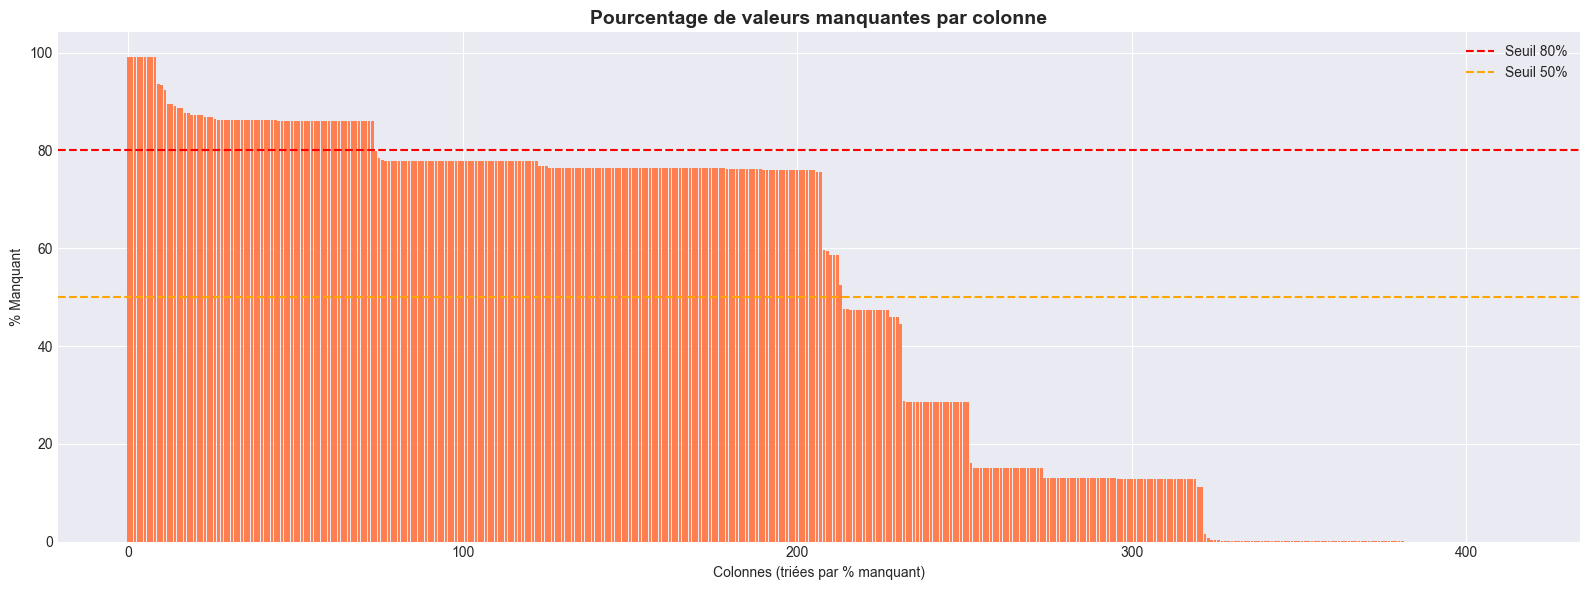

In [5]:
print("=" * 80)
print("ANALYSE DES VALEURS MANQUANTES")
print("=" * 80)

missing = train.isnull().sum()
missing_pct = (missing / len(train)) * 100

missing_df = pd.DataFrame({
    'Colonne': missing.index,
    'Manquantes': missing.values,
    'Pourcentage': missing_pct.values
}).sort_values('Pourcentage', ascending=False)

print(f"\n📊 Colonnes avec valeurs manquantes: {(missing > 0).sum()} / {train.shape[1]}")
print(f"📊 Colonnes avec >50% manquantes: {(missing_pct > 50).sum()}")
print(f"📊 Colonnes avec >80% manquantes: {(missing_pct > 80).sum()}")
print(f"📊 Colonnes avec >90% manquantes: {(missing_pct > 90).sum()}")

print("\n🔝 Top 20 colonnes avec le plus de valeurs manquantes:")
display(missing_df[missing_df['Manquantes'] > 0].head(20))

# Visualisation
fig, ax = plt.subplots(figsize=(16, 6))
cols_missing = missing_pct[missing_pct > 0].sort_values(ascending=False)
ax.bar(range(len(cols_missing)), cols_missing.values, color='coral')
ax.axhline(y=80, color='red', linestyle='--', label='Seuil 80%')
ax.axhline(y=50, color='orange', linestyle='--', label='Seuil 50%')
ax.set_title('Pourcentage de valeurs manquantes par colonne', fontsize=14, fontweight='bold')
ax.set_xlabel('Colonnes (triées par % manquant)')
ax.set_ylabel('% Manquant')
ax.legend()
plt.tight_layout()
plt.show()

## ✅ Étape 6: Statistiques descriptives

In [6]:
print("=" * 80)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 80)

# Focus sur les features principales
key_num_cols = ['TransactionAmt', 'TransactionDT'] + [c for c in card_cols if c in num_cols][:3] + c_cols[:5] + d_cols[:5]
key_num_cols = [c for c in key_num_cols if c in train.select_dtypes(include='number').columns]

print("\n📊 Statistiques des features numériques principales:")
display(train[key_num_cols].describe())

print("\n📊 Features catégorielles:")
for col in cat_cols:
    print(f"\n   {col}: {train[col].nunique()} valeurs uniques | "
          f"{train[col].isnull().sum()/len(train)*100:.1f}% manquant")
    print(f"   Top 3: {train[col].value_counts().head(3).to_dict()}")

STATISTIQUES DESCRIPTIVES

📊 Statistiques des features numériques principales:


,TransactionAmt,TransactionDT,card1,card2,card3,C1,C2,C3,C4,C5,D1,D2,D3,D4,D5
count,590540.000000,5.905400e+05,590540.000000,581607.000000,588975.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,589271.000000,309743.000000,327662.000000,421618.000000,280699.000000
mean,135.027176,7.372311e+06,9898.734658,362.555488,153.194925,14.092458,15.269734,0.005644,4.092185,5.571526,94.347568,169.563231,28.343348,140.002441,42.335965
std,239.162522,4.617224e+06,4901.170153,157.793246,11.336444,133.569018,154.668899,0.150536,68.848459,25.786976,157.660387,177.315865,62.384721,191.096774,89.000144
min,0.251000,8.640000e+04,1000.000000,100.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-122.000000,0.000000
25%,43.321000,3.027058e+06,6019.000000,214.000000,150.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,26.000000,1.000000,0.000000,1.000000
50%,68.769000,7.306528e+06,9678.000000,361.000000,150.000000,1.000000,1.000000,0.000000,0.000000,0.000000,3.000000,97.000000,8.000000,26.000000,10.000000
75%,125.000000,1.124662e+07,14184.000000,512.000000,150.000000,3.000000,3.000000,0.000000,0.000000,1.000000,122.000000,276.000000,27.000000,253.000000,32.000000
max,31937.391000,1.581113e+07,18396.000000,600.000000,231.000000,4685.000000,5691.000000,26.000000,2253.000000,349.000000,640.000000,640.000000,819.000000,869.000000,819.000000



📊 Features catégorielles:

   ProductCD: 5 valeurs uniques | 0.0% manquant
   Top 3: {'W': 439670, 'C': 68519, 'R': 37699}

   card4: 4 valeurs uniques | 0.3% manquant
   Top 3: {'visa': 384767, 'mastercard': 189217, 'american express': 8328}

   card6: 4 valeurs uniques | 0.3% manquant
   Top 3: {'debit': 439938, 'credit': 148986, 'debit or credit': 30}

   P_emaildomain: 59 valeurs uniques | 16.0% manquant
   Top 3: {'gmail.com': 228355, 'yahoo.com': 100934, 'hotmail.com': 45250}

   R_emaildomain: 60 valeurs uniques | 76.8% manquant
   Top 3: {'gmail.com': 57147, 'hotmail.com': 27509, 'anonymous.com': 20529}

   M1: 2 valeurs uniques | 45.9% manquant
   Top 3: {'T': 319415, 'F': 25}

   M2: 2 valeurs uniques | 45.9% manquant
   Top 3: {'T': 285468, 'F': 33972}

   M3: 2 valeurs uniques | 45.9% manquant
   Top 3: {'T': 251731, 'F': 67709}

   M4: 3 valeurs uniques | 47.7% manquant
   Top 3: {'M0': 196405, 'M2': 59865, 'M1': 52826}

   M5: 2 valeurs uniques | 59.3% manquant
   Top 3:

## ✅ Étape 7: Distribution de la cible (isFraud)

DISTRIBUTION DE LA CIBLE (isFraud)

📊 Classe 0 (Légitime): 569,877 transactions (96.50%)
📊 Classe 1 (Fraude):   20,663 transactions (3.50%)

⚖️ Ratio Légitime/Fraude: 27.6:1
⚠️ Dataset déséquilibré!


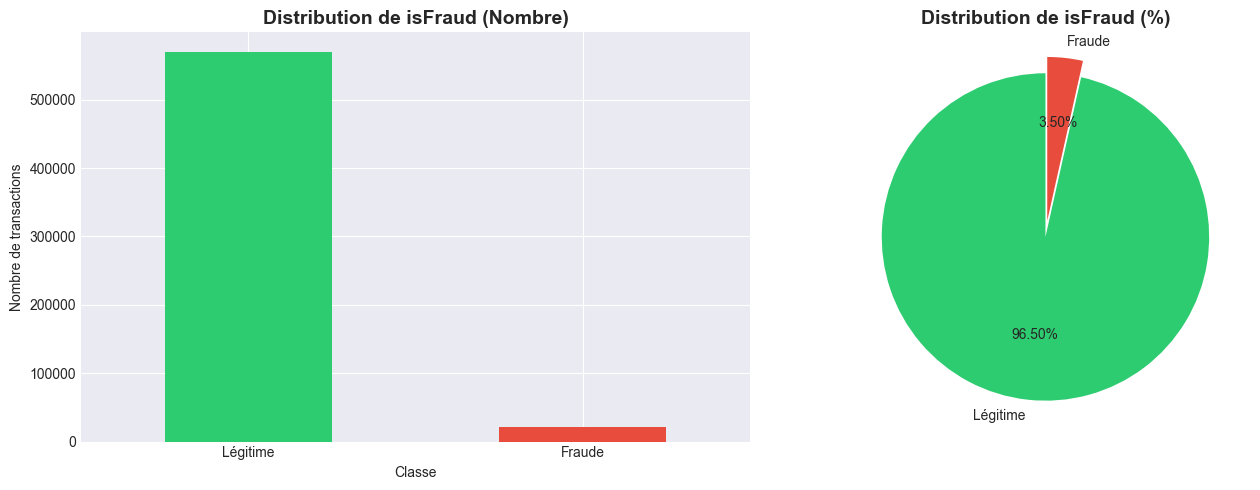

In [7]:
print("=" * 80)
print("DISTRIBUTION DE LA CIBLE (isFraud)")
print("=" * 80)

class_counts = train['isFraud'].value_counts()
class_pct = train['isFraud'].value_counts(normalize=True) * 100

print(f"\n📊 Classe 0 (Légitime): {class_counts[0]:,} transactions ({class_pct[0]:.2f}%)")
print(f"📊 Classe 1 (Fraude):   {class_counts[1]:,} transactions ({class_pct[1]:.2f}%)")

ratio = class_counts[0] / class_counts[1]
print(f"\n⚖️ Ratio Légitime/Fraude: {ratio:.1f}:1")
print(f"⚠️ Dataset déséquilibré!")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution de isFraud (Nombre)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre de transactions')
axes[0].set_xticklabels(['Légitime', 'Fraude'], rotation=0)

axes[1].pie(class_counts, labels=['Légitime', 'Fraude'], autopct='%1.2f%%',
            startangle=90, colors=['#2ecc71', '#e74c3c'], explode=(0, 0.1))
axes[1].set_title('Distribution de isFraud (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## ✅ Étape 8: Analyse de TransactionAmt (Montant)

ANALYSE DE TransactionAmt (Montant)

💰 Statistiques globales:
count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

💰 Par classe:

   Légitime: mean=134.51, median=68.50, max=31937.39

   Fraude: mean=149.24, median=75.00, max=5191.00


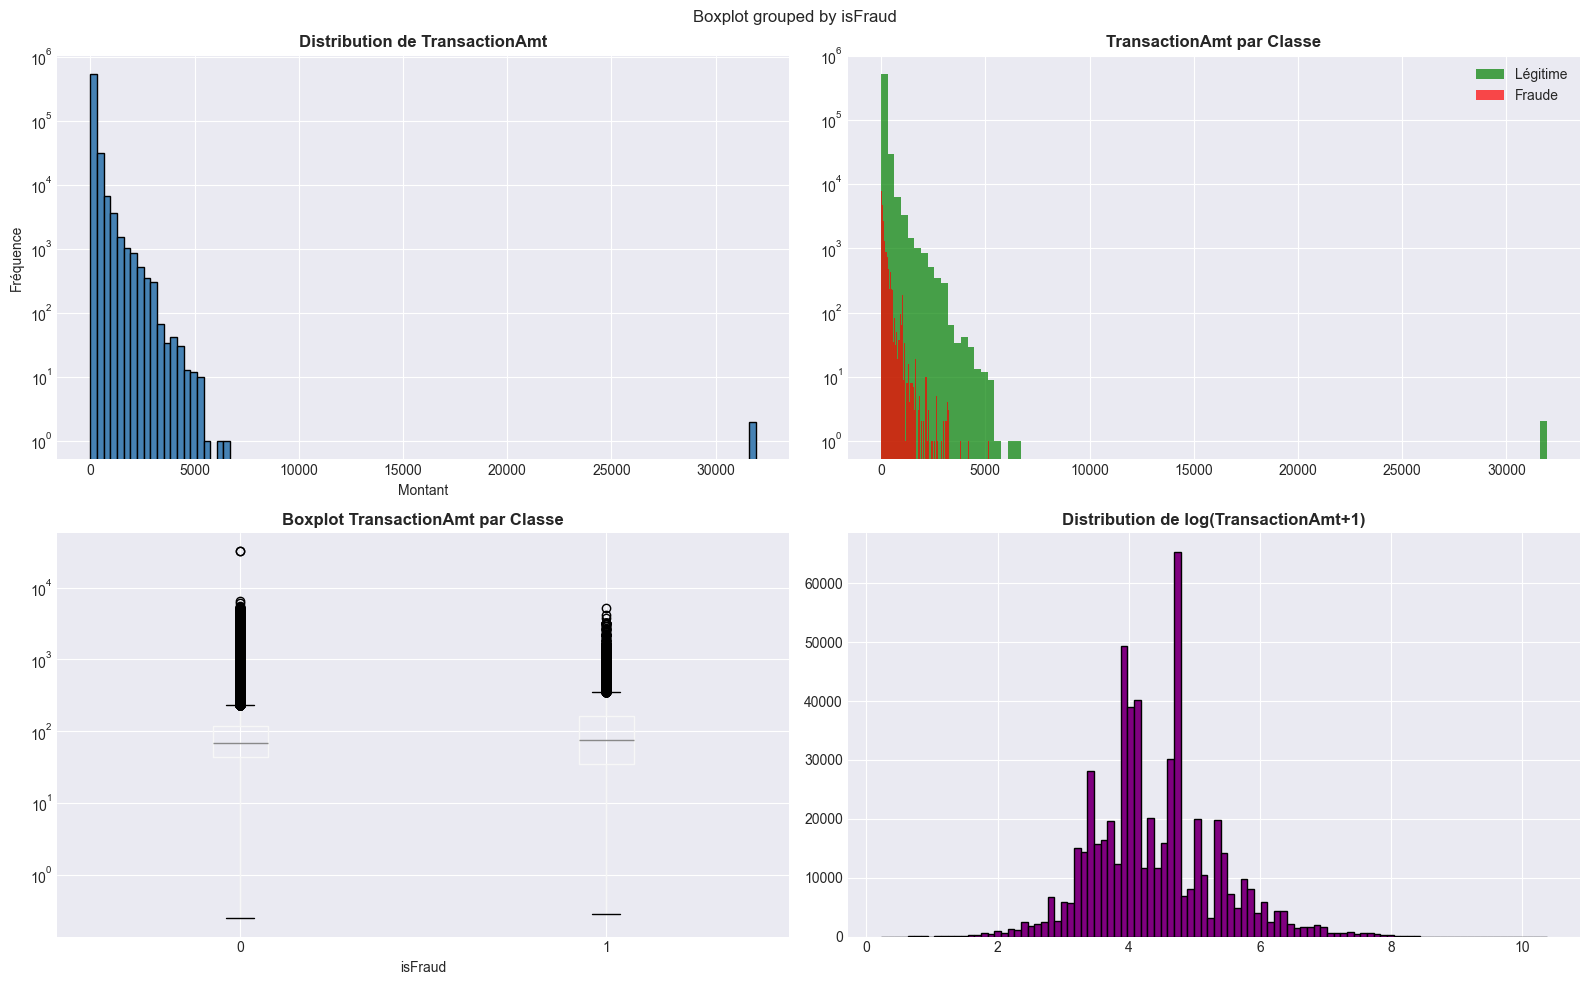

In [8]:
print("=" * 80)
print("ANALYSE DE TransactionAmt (Montant)")
print("=" * 80)

print(f"\n💰 Statistiques globales:")
print(train['TransactionAmt'].describe())

print(f"\n💰 Par classe:")
for cls, label in [(0, 'Légitime'), (1, 'Fraude')]:
    subset = train[train['isFraud'] == cls]['TransactionAmt']
    print(f"\n   {label}: mean={subset.mean():.2f}, median={subset.median():.2f}, "
          f"max={subset.max():.2f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(train['TransactionAmt'], bins=100, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribution de TransactionAmt', fontweight='bold')
axes[0, 0].set_xlabel('Montant')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_yscale('log')

train[train['isFraud'] == 0]['TransactionAmt'].hist(bins=100, alpha=0.7, label='Légitime', color='green', ax=axes[0, 1])
train[train['isFraud'] == 1]['TransactionAmt'].hist(bins=100, alpha=0.7, label='Fraude', color='red', ax=axes[0, 1])
axes[0, 1].set_title('TransactionAmt par Classe', fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].legend()

train.boxplot(column='TransactionAmt', by='isFraud', ax=axes[1, 0])
axes[1, 0].set_title('Boxplot TransactionAmt par Classe', fontweight='bold')
axes[1, 0].set_yscale('log')

axes[1, 1].hist(np.log1p(train['TransactionAmt']), bins=100, color='purple', edgecolor='black')
axes[1, 1].set_title('Distribution de log(TransactionAmt+1)', fontweight='bold')

plt.tight_layout()
plt.show()

## ✅ Étape 9: Analyse de TransactionDT (Temps)

ANALYSE DE TransactionDT (Feature temporelle)

⏱️ TransactionDT:
   Min: 86,400s (24.0h)
   Max: 15,811,131s (4392.0h)
   Durée couverte: 182.0 jours


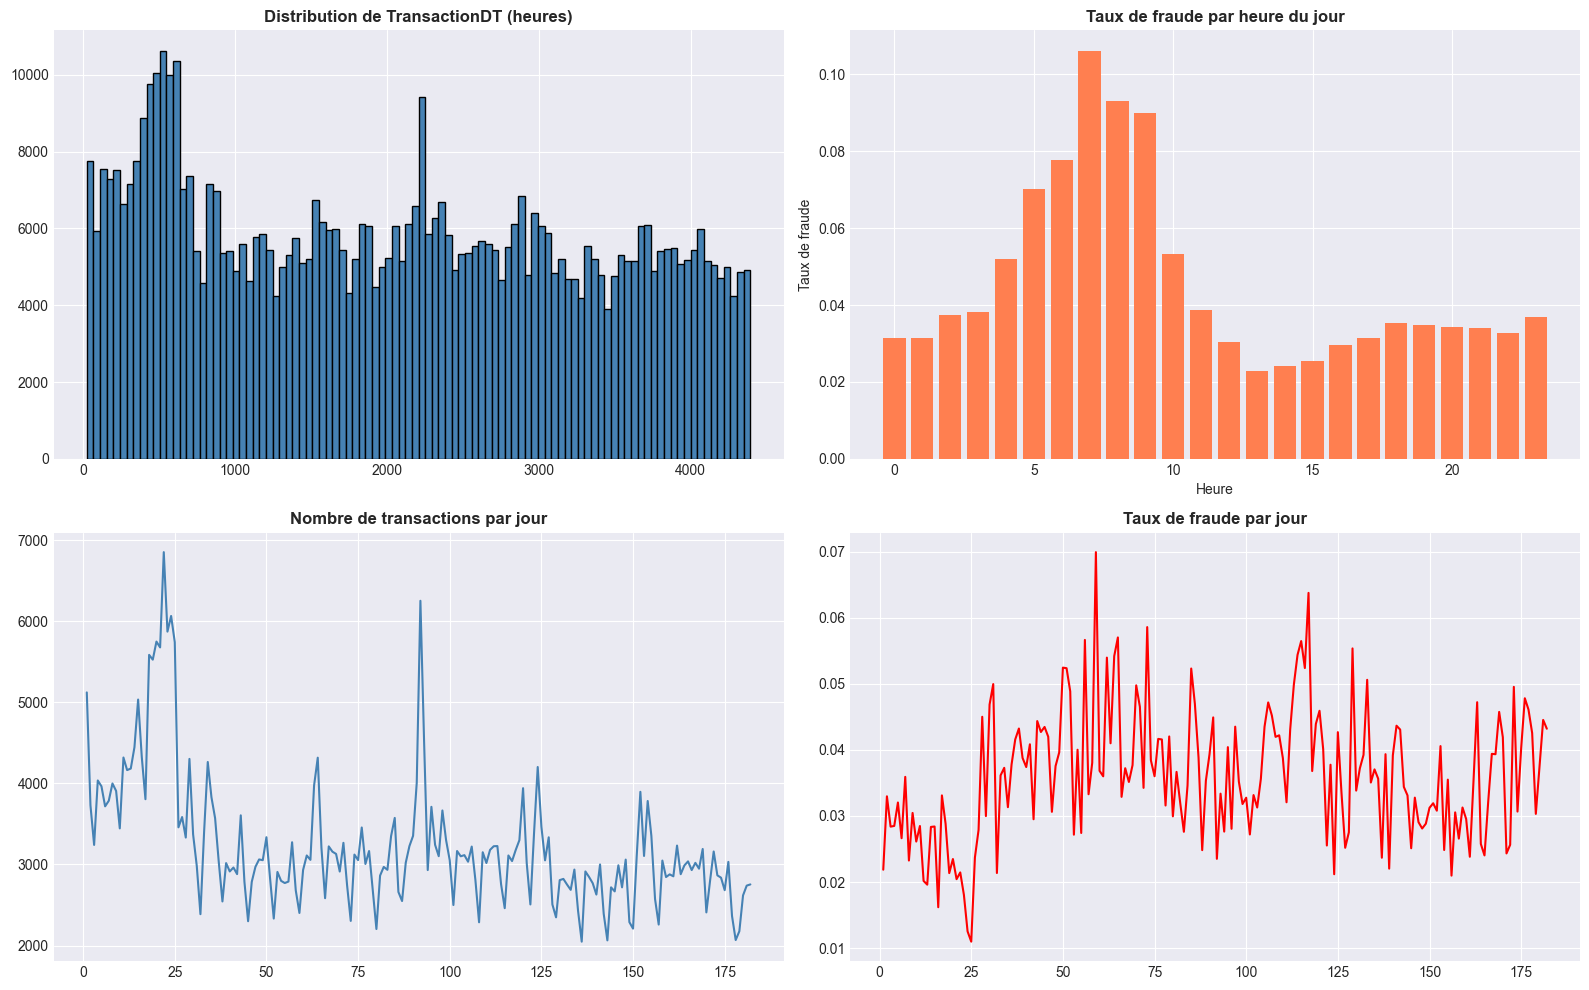

In [9]:
print("=" * 80)
print("ANALYSE DE TransactionDT (Feature temporelle)")
print("=" * 80)

# TransactionDT est un timedelta depuis une référence inconnue
print(f"\n⏱️ TransactionDT:")
print(f"   Min: {train['TransactionDT'].min():,.0f}s ({train['TransactionDT'].min()/3600:.1f}h)")
print(f"   Max: {train['TransactionDT'].max():,.0f}s ({train['TransactionDT'].max()/3600:.1f}h)")
print(f"   Durée couverte: {(train['TransactionDT'].max() - train['TransactionDT'].min())/86400:.1f} jours")

# Features temporelles dérivées (pour analyse seulement)
train['_hour'] = (train['TransactionDT'] / 3600) % 24
train['_day'] = (train['TransactionDT'] / 86400).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(train['TransactionDT'] / 3600, bins=100, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribution de TransactionDT (heures)', fontweight='bold')

# Taux de fraude par heure du jour
fraud_by_hour = train.groupby(train['_hour'].astype(int))['isFraud'].mean()
axes[0, 1].bar(fraud_by_hour.index, fraud_by_hour.values, color='coral')
axes[0, 1].set_title('Taux de fraude par heure du jour', fontweight='bold')
axes[0, 1].set_xlabel('Heure')
axes[0, 1].set_ylabel('Taux de fraude')

# Transactions par jour
txn_by_day = train.groupby('_day').size()
axes[1, 0].plot(txn_by_day.index, txn_by_day.values, color='steelblue')
axes[1, 0].set_title('Nombre de transactions par jour', fontweight='bold')

# Taux de fraude par jour
fraud_by_day = train.groupby('_day')['isFraud'].mean()
axes[1, 1].plot(fraud_by_day.index, fraud_by_day.values, color='red')
axes[1, 1].set_title('Taux de fraude par jour', fontweight='bold')

plt.tight_layout()
plt.show()

# Nettoyer les colonnes temporaires
train.drop(['_hour', '_day'], axis=1, inplace=True)

## ✅ Étape 10: Analyse des features catégorielles

ANALYSE DES FEATURES CATÉGORIELLES


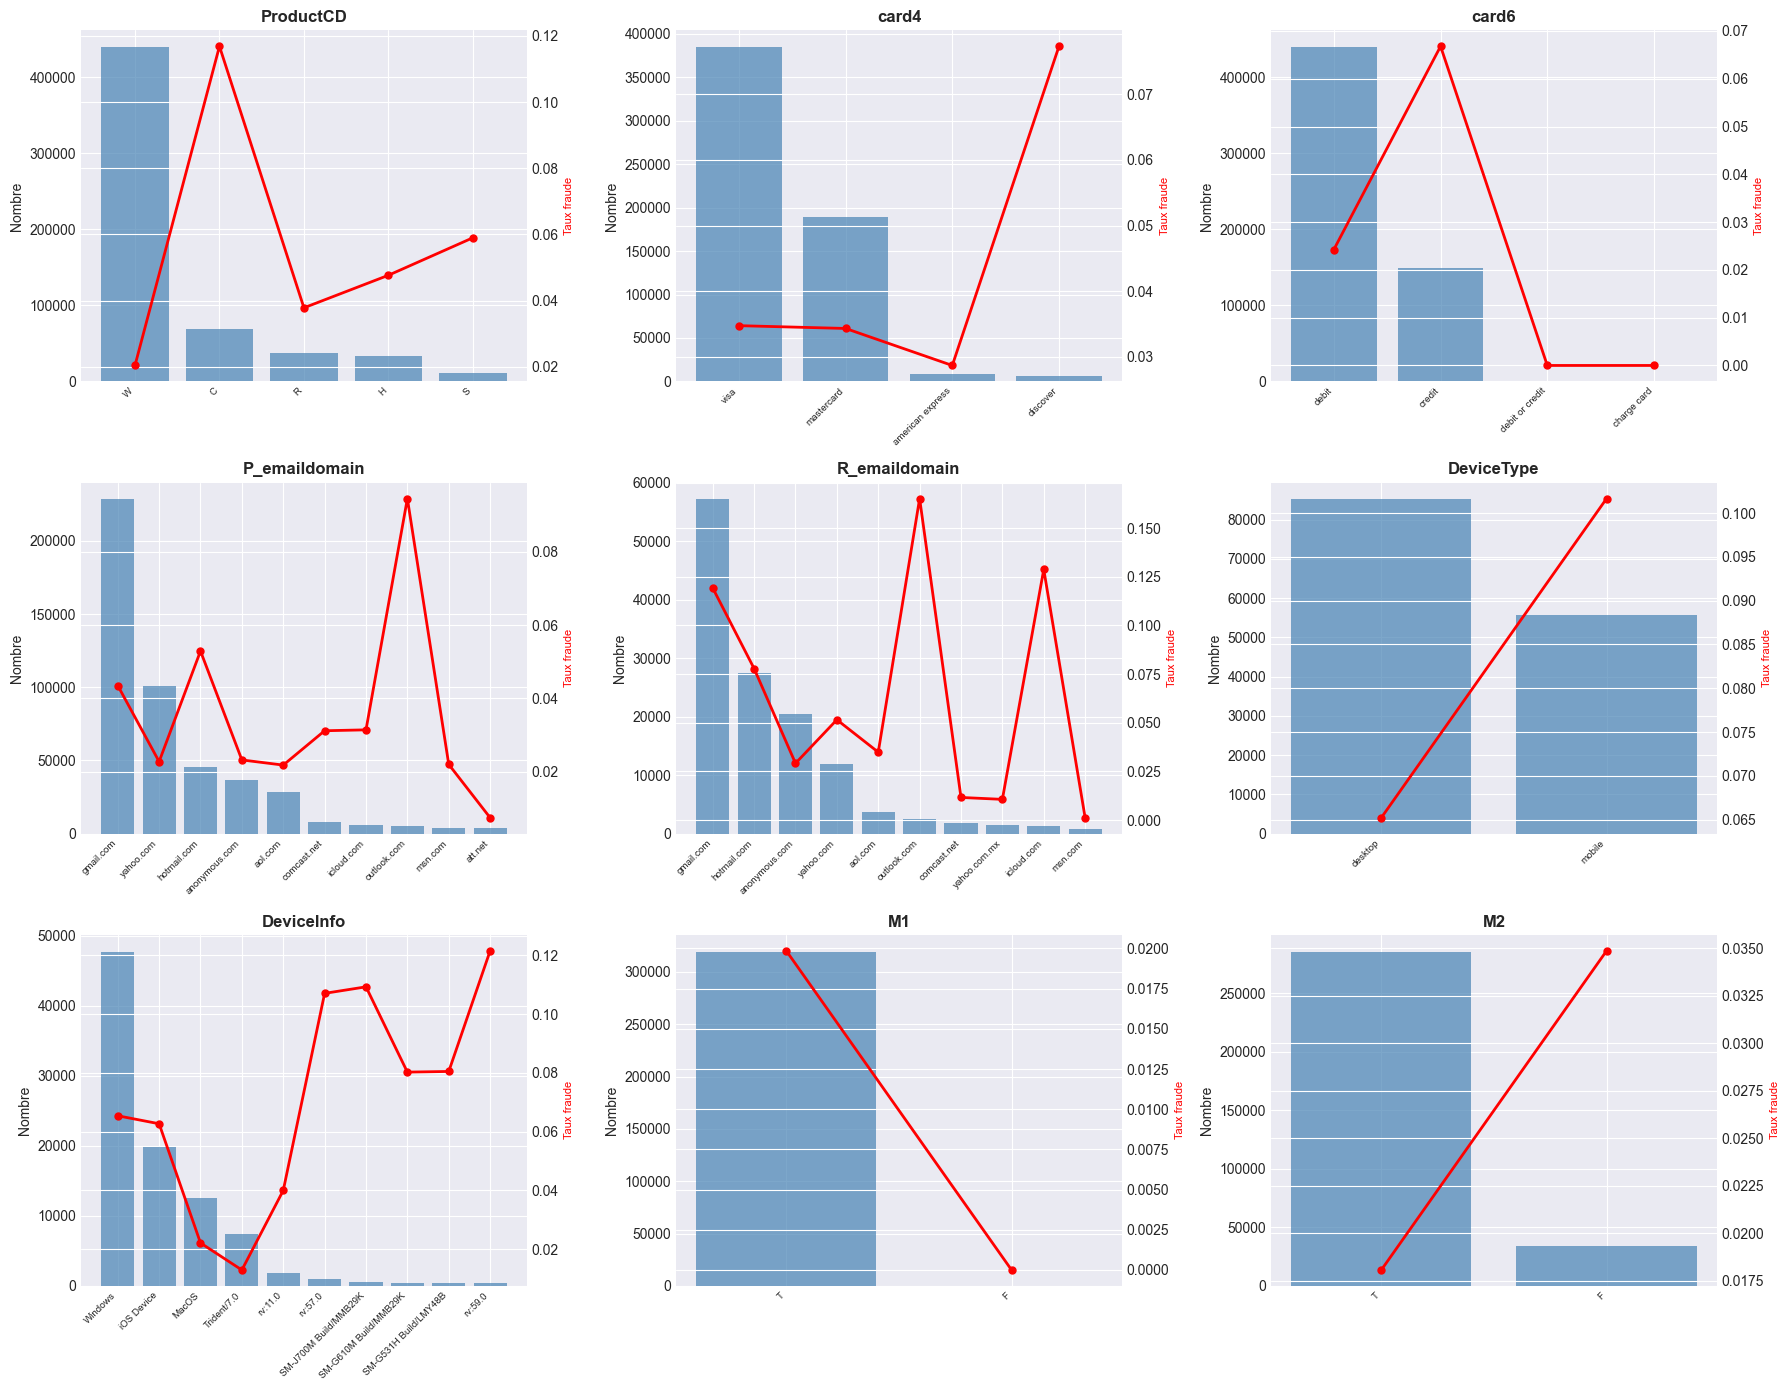


📊 Résumé des features catégorielles:
   ProductCD: 5 valeurs uniques, 0.0% manquant
   card4: 4 valeurs uniques, 0.3% manquant
   card6: 4 valeurs uniques, 0.3% manquant
   P_emaildomain: 59 valeurs uniques, 16.0% manquant
   R_emaildomain: 60 valeurs uniques, 76.8% manquant
   DeviceType: 2 valeurs uniques, 76.2% manquant
   DeviceInfo: 1786 valeurs uniques, 79.9% manquant
   M1: 2 valeurs uniques, 45.9% manquant
   M2: 2 valeurs uniques, 45.9% manquant
   M3: 2 valeurs uniques, 45.9% manquant
   M4: 3 valeurs uniques, 47.7% manquant
   M5: 2 valeurs uniques, 59.3% manquant
   M6: 2 valeurs uniques, 28.7% manquant
   M7: 2 valeurs uniques, 58.6% manquant
   M8: 2 valeurs uniques, 58.6% manquant
   M9: 2 valeurs uniques, 58.6% manquant


In [10]:
print("=" * 80)
print("ANALYSE DES FEATURES CATÉGORIELLES")
print("=" * 80)

cat_features = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain',
                'DeviceType', 'DeviceInfo'] + m_cols
cat_features = [c for c in cat_features if c in train.columns]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(cat_features[:9]):
    data = train[col].value_counts().head(10)
    fraud_rate = train.groupby(col)['isFraud'].mean().reindex(data.index)

    ax = axes[idx]
    bars = ax.bar(range(len(data)), data.values, color='steelblue', alpha=0.7)
    ax2 = ax.twinx()
    ax2.plot(range(len(data)), fraud_rate.values, 'ro-', linewidth=2, markersize=5)
    ax2.set_ylabel('Taux fraude', color='red', fontsize=8)

    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data.index, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Nombre')

plt.tight_layout()
plt.show()

# Résumé
print("\n📊 Résumé des features catégorielles:")
for col in cat_features:
    print(f"   {col}: {train[col].nunique()} valeurs uniques, "
          f"{train[col].isnull().sum()/len(train)*100:.1f}% manquant")

## ✅ Étape 11: Analyse des corrélations

ANALYSE DES CORRÉLATIONS

🔍 Top 15 features corrélées positivement avec isFraud:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
dtype: float64

🔍 Top 15 features corrélées négativement avec isFraud:
V35     -0.077116
D15     -0.077519
D2      -0.083583
id_07   -0.084768
V70     -0.100900
V30     -0.103088
V69     -0.104521
V91     -0.105453
V29     -0.107852
V90     -0.110168
V49     -0.110920
V48     -0.115786
id_01   -0.120099
D7      -0.127199
D8      -0.142636
dtype: float64


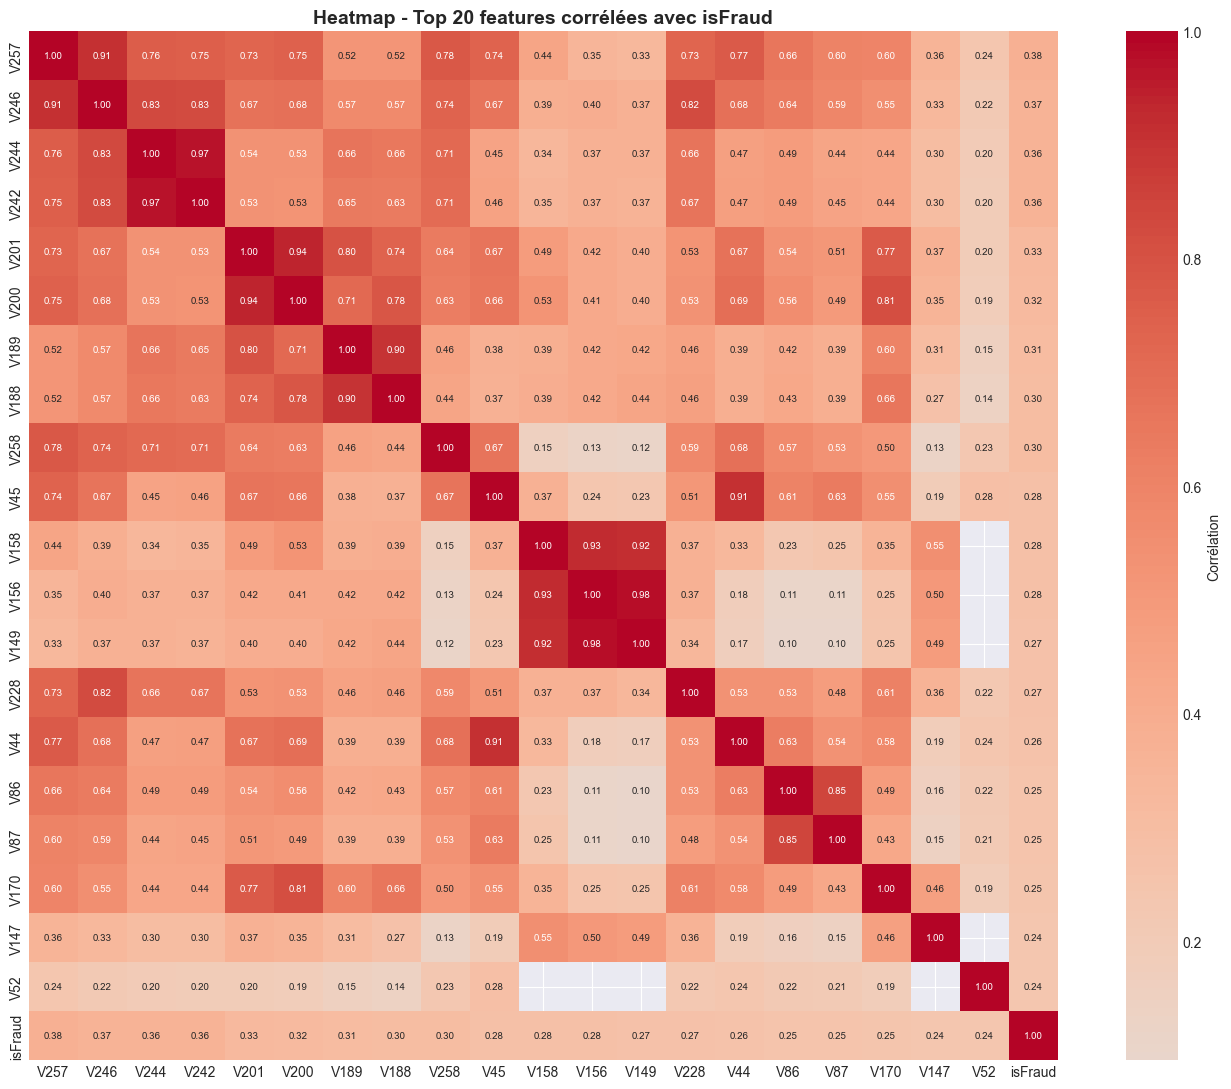

In [11]:
print("=" * 80)
print("ANALYSE DES CORRÉLATIONS")
print("=" * 80)

# Corrélation avec la cible
num_features = train.select_dtypes(include='number').columns.drop(['TransactionID', 'isFraud'])
corr_with_fraud = train[num_features].corrwith(train['isFraud']).sort_values(ascending=False)

print("\n🔍 Top 15 features corrélées positivement avec isFraud:")
print(corr_with_fraud.head(15))

print("\n🔍 Top 15 features corrélées négativement avec isFraud:")
print(corr_with_fraud.tail(15))

# Heatmap top corrélées
top_features = corr_with_fraud.abs().sort_values(ascending=False).head(20).index.tolist()
top_features_with_target = top_features + ['isFraud']
corr_matrix = train[top_features_with_target].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, cbar_kws={'label': 'Corrélation'},
            annot_kws={'size': 7})
ax.set_title('Heatmap - Top 20 features corrélées avec isFraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ✅ Étape 12: Traiter les valeurs manquantes

In [14]:
print("=" * 80)
print("TRAITEMENT DES VALEURS MANQUANTES")
print("=" * 80)

# Stratégie: supprimer les colonnes avec plus de 80% de valeurs manquantes
threshold = 80
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
cols_to_drop = [c for c in cols_to_drop if c not in ['isFraud', 'TransactionID']]

print(f"\n🗑️ Colonnes à supprimer (>{threshold}% manquantes): {len(cols_to_drop)}")

train_clean = train.drop(columns=cols_to_drop)
test_clean = test.drop(columns=cols_to_drop)

print(f"   Shape train avant: {train.shape} → après: {train_clean.shape}")
print(f"   Shape test avant:  {test.shape} → après: {test_clean.shape}")

# Imputer les colonnes restantes
num_remaining = train_clean.select_dtypes(include='number').columns.drop(['TransactionID', 'isFraud'])
cat_remaining = train_clean.select_dtypes(include='object').columns

print(f"\n🔧 Imputation des colonnes restantes:")
print(f"   Numériques (médiane): {len(num_remaining)} colonnes")
print(f"   Catégorielles ('unknown'): {len(cat_remaining)} colonnes")

for col in num_remaining:
    median_val = train_clean[col].median()
    train_clean[col] = train_clean[col].fillna(median_val)
    test_clean[col] = test_clean[col].fillna(median_val)

for col in cat_remaining:
    train_clean[col] = train_clean[col].fillna('unknown')
    test_clean[col] = test_clean[col].fillna('unknown')

print(f"\n✅ Valeurs manquantes restantes (train): {train_clean.isnull().sum().sum()}")
print(f"✅ Valeurs manquantes restantes (test):  {test_clean.isnull().sum().sum()}")

TRAITEMENT DES VALEURS MANQUANTES

🗑️ Colonnes à supprimer (>80% manquantes): 74
   Shape train avant: (590540, 434) → après: (590540, 360)
   Shape test avant:  (506691, 433) → après: (506691, 359)

🔧 Imputation des colonnes restantes:
   Numériques (médiane): 332 colonnes
   Catégorielles ('unknown'): 26 colonnes

✅ Valeurs manquantes restantes (train): 0
✅ Valeurs manquantes restantes (test):  0


## ✅ Étape 13: Détecter les doublons

In [15]:
print("=" * 80)
print("DÉTECTION DES DOUBLONS")
print("=" * 80)

cols_for_dup = [c for c in train_clean.columns if c != 'TransactionID']
duplicates = train_clean.duplicated(subset=cols_for_dup).sum()

print(f"\n📊 Lignes dupliquées: {duplicates:,}")

if duplicates > 0:
    print(f"   Pourcentage: {(duplicates / len(train_clean)) * 100:.4f}%")
    print("   ℹ️ Les doublons sont conservés (transactions similaires peuvent être légitimes)")
else:
    print("✅ Aucun doublon détecté")

print(f"\n📊 Shape actuel train: {train_clean.shape}")
print(f"📊 Shape actuel test:  {test_clean.shape}")

DÉTECTION DES DOUBLONS

📊 Lignes dupliquées: 3
   Pourcentage: 0.0005%
   ℹ️ Les doublons sont conservés (transactions similaires peuvent être légitimes)

📊 Shape actuel train: (590540, 360)
📊 Shape actuel test:  (506691, 359)


## ✅ Étape 14: Analyser les outliers

In [16]:
print("=" * 80)
print("ANALYSE DES OUTLIERS")
print("=" * 80)

def detect_outliers_iqr(data, column):
    """Détecter les outliers avec la méthode IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

print("\n💰 Outliers dans TransactionAmt:")
amt_outliers, lower, upper = detect_outliers_iqr(train_clean, 'TransactionAmt')
print(f"   Nombre: {len(amt_outliers):,} ({len(amt_outliers)/len(train_clean)*100:.2f}%)")
print(f"   Bornes IQR: [{lower:.2f}, {upper:.2f}]")
print(f"   Fraudes parmi outliers: {amt_outliers['isFraud'].sum():,} "
      f"({amt_outliers['isFraud'].mean()*100:.2f}%)")
print(f"   Fraudes hors outliers: "
      f"{train_clean[~train_clean.index.isin(amt_outliers.index)]['isFraud'].mean()*100:.2f}%")

print("\n⚠️ Décision: GARDER les outliers (informations cruciales pour détecter les fraudes)")
print("   Le RobustScaler sera utilisé pour atténuer l'impact des valeurs extrêmes")

ANALYSE DES OUTLIERS

💰 Outliers dans TransactionAmt:
   Nombre: 66,482 (11.26%)
   Bornes IQR: [-79.20, 247.52]
   Fraudes parmi outliers: 3,372 (5.07%)
   Fraudes hors outliers: 3.30%

⚠️ Décision: GARDER les outliers (informations cruciales pour détecter les fraudes)
   Le RobustScaler sera utilisé pour atténuer l'impact des valeurs extrêmes


## ✅ Étape 15: Encoder les variables catégorielles

In [17]:
print("=" * 80)
print("ENCODAGE DES VARIABLES CATÉGORIELLES")
print("=" * 80)

cat_cols_to_encode = train_clean.select_dtypes(include='object').columns.tolist()
print(f"\n📊 Colonnes catégorielles à encoder: {len(cat_cols_to_encode)}")

label_encoders = {}
for col in cat_cols_to_encode:
    le = LabelEncoder()
    # Combiner train + test pour un encodage cohérent
    combined = pd.concat([train_clean[col], test_clean[col]], axis=0)
    le.fit(combined)
    train_clean[col] = le.transform(train_clean[col])
    test_clean[col] = le.transform(test_clean[col])
    label_encoders[col] = le
    print(f"   ✅ {col}: {len(le.classes_)} classes")

print(f"\n✅ Toutes les colonnes catégorielles encodées (LabelEncoder)")
print(f"📊 Shape train: {train_clean.shape}")
print(f"📊 Shape test:  {test_clean.shape}")

ENCODAGE DES VARIABLES CATÉGORIELLES

📊 Colonnes catégorielles à encoder: 26
   ✅ ProductCD: 5 classes
   ✅ card4: 5 classes
   ✅ card6: 5 classes
   ✅ P_emaildomain: 61 classes
   ✅ R_emaildomain: 61 classes
   ✅ M1: 3 classes
   ✅ M2: 3 classes
   ✅ M3: 3 classes
   ✅ M4: 4 classes
   ✅ M5: 3 classes
   ✅ M6: 3 classes
   ✅ M7: 3 classes
   ✅ M8: 3 classes
   ✅ M9: 3 classes
   ✅ id_12: 3 classes
   ✅ id_15: 4 classes
   ✅ id_16: 3 classes
   ✅ id_28: 3 classes
   ✅ id_29: 3 classes
   ✅ id_31: 173 classes
   ✅ id_35: 3 classes
   ✅ id_36: 3 classes
   ✅ id_37: 3 classes
   ✅ id_38: 3 classes
   ✅ DeviceType: 3 classes
   ✅ DeviceInfo: 2800 classes

✅ Toutes les colonnes catégorielles encodées (LabelEncoder)
📊 Shape train: (590540, 360)
📊 Shape test:  (506691, 359)


## ✅ Étape 16: Normaliser les features numériques

In [18]:
print("=" * 80)
print("NORMALISATION DES FEATURES NUMÉRIQUES")
print("=" * 80)

# Colonnes à normaliser (exclure TransactionID et isFraud)
cols_to_scale = [c for c in train_clean.columns if c not in ['TransactionID', 'isFraud']]

scaler = RobustScaler()
train_clean[cols_to_scale] = scaler.fit_transform(train_clean[cols_to_scale])
test_clean[cols_to_scale] = scaler.transform(test_clean[cols_to_scale])

print(f"\n✅ {len(cols_to_scale)} colonnes normalisées avec RobustScaler")

print(f"\n📊 Statistiques après normalisation (5 premières colonnes):")
display(train_clean[cols_to_scale[:5]].describe())

NORMALISATION DES FEATURES NUMÉRIQUES

✅ 358 colonnes normalisées avec RobustScaler

📊 Statistiques après normalisation (5 premières colonnes):


,TransactionDT,TransactionAmt,ProductCD,card1,card2
count,590540.000000,5.905400e+05,590540.000000,590540.000000,590540.000000
mean,0.008003,8.112021e-01,-0.779243,0.027034,0.005158
std,0.561736,2.928078e+00,1.423926,0.600266,0.527257
min,-0.878408,-8.388692e-01,-4.000000,-1.062829,-0.878788
25%,-0.520644,-3.115611e-01,-1.000000,-0.448132,-0.491582
50%,0.000000,-8.698012e-17,0.000000,0.000000,0.000000
75%,0.479356,6.884389e-01,0.000000,0.551868,0.508418
max,1.034678,3.901691e+02,0.000000,1.067728,0.804714


## ✅ Étape 17: Créer les features (X) et target (y)

In [19]:
print("=" * 80)
print("CRÉATION DES FEATURES (X) ET TARGET (y)")
print("=" * 80)

# Séparer features et cible
X = train_clean.drop(['TransactionID', 'isFraud'], axis=1)
y = train_clean['isFraud']

X_test_final = test_clean.drop(['TransactionID'], axis=1)
test_ids = test_clean['TransactionID']

print(f"\n📊 Features (X): {X.shape}")
print(f"🎯 Target (y): {y.shape}")
print(f"   Distribution: {y.value_counts().to_dict()}")
print(f"\n📊 Test set: {X_test_final.shape}")

print("\n✅ Features et target créés avec succès")

CRÉATION DES FEATURES (X) ET TARGET (y)

📊 Features (X): (590540, 358)
🎯 Target (y): (590540,)
   Distribution: {0: 569877, 1: 20663}

📊 Test set: (506691, 358)

✅ Features et target créés avec succès


## ✅ Étape 18: Diviser les données (Train/Validation)

In [20]:
print("=" * 80)
print("DIVISION TRAIN / VALIDATION")
print("=" * 80)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Ensemble d'entraînement:")
print(f"   X_train: {X_train.shape}")
print(f"   Fraude: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")

print(f"\n📊 Ensemble de validation:")
print(f"   X_val: {X_val.shape}")
print(f"   Fraude: {y_val.sum():,} ({y_val.mean()*100:.2f}%)")

print(f"\n📊 Ensemble de test (compétition):")
print(f"   X_test: {X_test_final.shape}")

print("\n✅ Division effectuée avec stratification")

DIVISION TRAIN / VALIDATION

📊 Ensemble d'entraînement:
   X_train: (472432, 358)
   Fraude: 16,530 (3.50%)

📊 Ensemble de validation:
   X_val: (118108, 358)
   Fraude: 4,133 (3.50%)

📊 Ensemble de test (compétition):
   X_test: (506691, 358)

✅ Division effectuée avec stratification


## ✅ Étape 19: Analyser le déséquilibre des classes

ANALYSE DU DÉSÉQUILIBRE DES CLASSES

⚖️ Ratio Légitime/Fraude:
   Train:      27.6:1
   Validation: 27.6:1


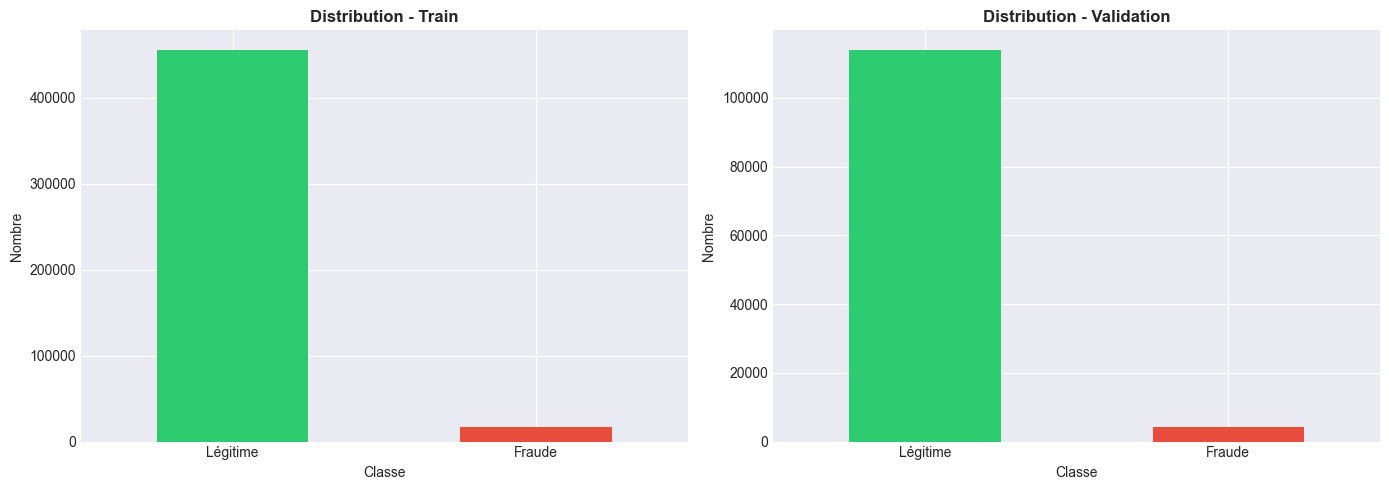


⚠️ Dataset déséquilibré - Stratégies recommandées pour le modeling:
   1. class_weight='balanced' dans les modèles (LogReg, RF, etc.)
   2. scale_pos_weight dans XGBoost/LightGBM
   3. SMOTE ou ADASYN (sur-échantillonnage synthétique)
   4. Métriques adaptées: AUC-ROC, F1-score, Precision-Recall AUC
   5. Threshold tuning sur la courbe Precision-Recall


In [21]:
print("=" * 80)
print("ANALYSE DU DÉSÉQUILIBRE DES CLASSES")
print("=" * 80)

train_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
val_ratio = y_val.value_counts()[0] / y_val.value_counts()[1]

print(f"\n⚖️ Ratio Légitime/Fraude:")
print(f"   Train:      {train_ratio:.1f}:1")
print(f"   Validation: {val_ratio:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution - Train', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre')
axes[0].set_xticklabels(['Légitime', 'Fraude'], rotation=0)

y_val.value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Distribution - Validation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Nombre')
axes[1].set_xticklabels(['Légitime', 'Fraude'], rotation=0)

plt.tight_layout()
plt.show()

print("\n⚠️ Dataset déséquilibré - Stratégies recommandées pour le modeling:")
print("   1. class_weight='balanced' dans les modèles (LogReg, RF, etc.)")
print("   2. scale_pos_weight dans XGBoost/LightGBM")
print("   3. SMOTE ou ADASYN (sur-échantillonnage synthétique)")
print("   4. Métriques adaptées: AUC-ROC, F1-score, Precision-Recall AUC")
print("   5. Threshold tuning sur la courbe Precision-Recall")

## ✅ Étape 20: Sauvegarder les données préparées

In [22]:
print("=" * 80)
print("SAUVEGARDE DES DONNÉES PRÉPARÉES")
print("=" * 80)

os.makedirs('../dataset/processed_data', exist_ok=True)

print("\n💾 Sauvegarde des ensembles de données...")

X_train.to_csv('../dataset/processed_data/X_train.csv', index=False)
X_val.to_csv('../dataset/processed_data/X_val.csv', index=False)
y_train.to_csv('../dataset/processed_data/y_train.csv', index=False)
y_val.to_csv('../dataset/processed_data/y_val.csv', index=False)
X_test_final.to_csv('../dataset/processed_data/X_test.csv', index=False)
test_ids.to_csv('../dataset/processed_data/test_ids.csv', index=False)

print("   ✅ X_train.csv, X_val.csv")
print("   ✅ y_train.csv, y_val.csv")
print("   ✅ X_test.csv, test_ids.csv")

print(f"\n✅ Données sauvegardées dans 'dataset/processed_data/'")

SAUVEGARDE DES DONNÉES PRÉPARÉES

💾 Sauvegarde des ensembles de données...
   ✅ X_train.csv, X_val.csv
   ✅ y_train.csv, y_val.csv
   ✅ X_test.csv, test_ids.csv

✅ Données sauvegardées dans 'dataset/processed_data/'


## ✅ Étape 21: Sauvegarder les transformateurs

In [23]:
print("=" * 80)
print("SAUVEGARDE DES TRANSFORMATEURS")
print("=" * 80)

os.makedirs('../models', exist_ok=True)

joblib.dump(scaler, '../models/robust_scaler.pkl')
joblib.dump(label_encoders, '../models/label_encoders.pkl')
joblib.dump(cols_to_drop, '../models/cols_dropped.pkl')
joblib.dump(cols_to_scale, '../models/cols_to_scale.pkl')

print("   ✅ robust_scaler.pkl")
print("   ✅ label_encoders.pkl")
print("   ✅ cols_dropped.pkl")
print("   ✅ cols_to_scale.pkl")

print("\n✅ Transformateurs sauvegardés dans 'models/'")

SAUVEGARDE DES TRANSFORMATEURS
   ✅ robust_scaler.pkl
   ✅ label_encoders.pkl
   ✅ cols_dropped.pkl
   ✅ cols_to_scale.pkl

✅ Transformateurs sauvegardés dans 'models/'


## ✅ Étape 22: Rapport de préparation

In [24]:
print("=" * 80)
print("RAPPORT DE PRÉPARATION DES DONNÉES")
print("=" * 80)

report = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║              RAPPORT DE PRÉPARATION DES DONNÉES                            ║
║              Détection de Fraude - IEEE-CIS                                ║
║              Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}                               ║
╚══════════════════════════════════════════════════════════════════════════════╝

📊 DATASET ORIGINAL
   • Transactions (train): {train.shape[0]:,} lignes x {train.shape[1]} colonnes
   • Transactions (test):  {test.shape[0]:,} lignes x {test.shape[1]} colonnes
   • Fusion identity: left join sur TransactionID

🔍 QUALITÉ DES DONNÉES
   • Colonnes supprimées (>{threshold}% manquantes): {len(cols_to_drop)}
   • Imputation numérique: médiane
   • Imputation catégorielle: 'unknown'
   • Doublons: {duplicates:,} trouvés

🎯 CIBLE (isFraud)
   • Légitime: {class_counts[0]:,} ({class_pct[0]:.2f}%)
   • Fraude:   {class_counts[1]:,} ({class_pct[1]:.2f}%)
   • Ratio:    {ratio:.1f}:1

🔧 TRANSFORMATIONS
   • Encodage catégoriel: LabelEncoder ({len(cat_cols_to_encode)} colonnes)
   • Normalisation: RobustScaler ({len(cols_to_scale)} colonnes)

📂 DONNÉES FINALES
   • Train:      {X_train.shape}
   • Validation:  {X_val.shape}
   • Test:       {X_test_final.shape}
   • Features:   {X_train.shape[1]}

💾 FICHIERS SAUVEGARDÉS
   processed_data/: X_train, X_val, y_train, y_val, X_test, test_ids
   models/:         robust_scaler, label_encoders, cols_dropped, cols_to_scale

✅ PROCHAINES ÉTAPES
   1. Feature engineering avancé (features temporelles, agrégations)
   2. Modélisation (LightGBM, XGBoost, Random Forest)
   3. Évaluation (AUC-ROC, F1, Precision-Recall)
   4. Optimisation des hyperparamètres
"""

print(report)

with open('../dataset/processed_data/preparation_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("✅ Rapport sauvegardé")
print("\n🎉 PRÉPARATION DES DONNÉES TERMINÉE! 🎉")

RAPPORT DE PRÉPARATION DES DONNÉES

╔══════════════════════════════════════════════════════════════════════════════╗
║              RAPPORT DE PRÉPARATION DES DONNÉES                            ║
║              Détection de Fraude - IEEE-CIS                                ║
║              Date: 2026-03-04 19:51:09                               ║
╚══════════════════════════════════════════════════════════════════════════════╝

📊 DATASET ORIGINAL
   • Transactions (train): 590,540 lignes x 434 colonnes
   • Transactions (test):  506,691 lignes x 433 colonnes
   • Fusion identity: left join sur TransactionID

🔍 QUALITÉ DES DONNÉES
   • Colonnes supprimées (>80% manquantes): 74
   • Imputation numérique: médiane
   • Imputation catégorielle: 'unknown'
   • Doublons: 3 trouvés

🎯 CIBLE (isFraud)
   • Légitime: 569,877 (96.50%)
   • Fraude:   20,663 (3.50%)
   • Ratio:    27.6:1

🔧 TRANSFORMATIONS
   • Encodage catégoriel: LabelEncoder (26 colonnes)
   • Normalisation: RobustScaler (358 colo

---

## Résumé de la Préparation

### Dataset: IEEE-CIS Fraud Detection

Ce dataset contient des données de transactions e-commerce avec des features d'identité.
L'objectif est de détecter les transactions frauduleuses (`isFraud`).

### Étapes réalisées

1. Chargement et fusion des tables **transaction + identity** (left join sur TransactionID)
2. Analyse exploratoire complète (distributions, corrélations, features catégorielles)
3. Suppression des colonnes avec **>80% de valeurs manquantes**
4. Imputation (médiane pour numériques, 'unknown' pour catégorielles)
5. Encodage des variables catégorielles (**LabelEncoder**)
6. Normalisation avec **RobustScaler** (résistant aux outliers)
7. Division train/validation **(80/20 stratifié)**
8. Sauvegarde des données et transformateurs

### Adéquation avec le projet

Ce dataset est **parfaitement adapté** pour la détection de fraude car il contient :
- **TransactionAmt** : montant de la transaction
- **TransactionDT** : information temporelle (heure, jour)
- **ProductCD** : type de transaction (W, H, C, S, R)
- **card1-card6** : informations sur la carte (type, réseau)
- **DeviceType/DeviceInfo** : appareil utilisé
- **V1-V339** : features Vesta propriétaires
- **id_01-id_38** : features d'identité

### Prochaine Étape

- **02_modeling.ipynb** : Entraîner et évaluer des modèles (LightGBM, XGBoost, etc.)
- Utiliser `scale_pos_weight` ou `class_weight='balanced'` pour gérer le déséquilibre
- Métriques adaptées : AUC-ROC, PR-AUC, F1-score

---

---

## Task 3 and Task 4: MLflow Experiments and Random Forest Analysis

This section implements the required experiments, logs all runs to MLflow, and prepares the reports for Task 3 and Task 4.

In [4]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

project_root = Path("..").resolve()
data_dir = project_root / "dataset" / "processed_data"
reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)
mlruns_dir = project_root / "mlruns"
mlruns_dir.mkdir(exist_ok=True)

X_train = pd.read_csv(data_dir / "X_train.csv")
X_val = pd.read_csv(data_dir / "X_val.csv")
y_train = pd.read_csv(data_dir / "y_train.csv").iloc[:, 0]
y_val = pd.read_csv(data_dir / "y_val.csv").iloc[:, 0]

print("X_train:", X_train.shape, "X_val:", X_val.shape)
print("Class distribution (train):")
print(y_train.value_counts(normalize=True).sort_index().round(4))

mlflow.set_tracking_uri(mlruns_dir.as_uri())
mlflow.set_experiment("fraud_detection_task3_task4")

USE_SAMPLE_FOR_COSTLY = True
COSTLY_MAX_SAMPLES = 100000


def sample_if_needed(X, y, max_samples, random_state):
    if not USE_SAMPLE_FOR_COSTLY or len(X) <= max_samples:
        return X, y, False
    X_sample = X.sample(max_samples, random_state=random_state)
    y_sample = y.loc[X_sample.index]
    return X_sample, y_sample, True


def get_y_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None


def compute_metrics(y_true, y_pred, y_score=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    return metrics


def log_confusion_matrix(y_true, y_pred, artifact_name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for (i, j), value in np.ndenumerate(cm):
        ax.text(j, i, int(value), ha="center", va="center")
    fig.tight_layout()
    path = reports_dir / artifact_name
    fig.savefig(path, dpi=150)
    plt.close(fig)
    mlflow.log_artifact(str(path))


def run_and_log(model_name, model, X_tr, y_tr, X_va, y_va, params, tags=None):
    if mlflow.active_run() is not None:
        mlflow.end_run()
    with mlflow.start_run(run_name=model_name) as run:
        mlflow.log_params(params)
        if tags:
            mlflow.set_tags(tags)
        mlflow.log_param("n_train", len(X_tr))
        mlflow.log_param("n_val", len(X_va))

        model.fit(X_tr, y_tr)

        y_pred_tr = model.predict(X_tr)
        y_pred_va = model.predict(X_va)

        y_score_tr = get_y_score(model, X_tr)
        y_score_va = get_y_score(model, X_va)

        train_metrics = compute_metrics(y_tr, y_pred_tr, y_score_tr)
        val_metrics = compute_metrics(y_va, y_pred_va, y_score_va)

        mlflow.log_metrics({f"train_{k}": v for k, v in train_metrics.items()})
        mlflow.log_metrics({f"val_{k}": v for k, v in val_metrics.items()})

        mlflow.sklearn.log_model(model, artifact_path="model")
        return train_metrics, val_metrics, model, run.info.run_id

X_train: (472432, 358) X_val: (118108, 358)
Class distribution (train):
isFraud
0    0.965
1    0.035
Name: proportion, dtype: float64


### Task 3: Experimentation and Comparison (MLflow)

In [2]:
results = []


def record_result(model_label, params, train_metrics, val_metrics, run_id):
    results.append(
        {
            "model": model_label,
            "params": params,
            "run_id": run_id,
            "train_f1": train_metrics.get("f1"),
            "val_f1": val_metrics.get("f1"),
            "val_precision": val_metrics.get("precision"),
            "val_recall": val_metrics.get("recall"),
            "val_roc_auc": val_metrics.get("roc_auc"),
            "val_accuracy": val_metrics.get("accuracy"),
        }
    )


# KNN
X_knn, y_knn, sampled_knn = sample_if_needed(
    X_train, y_train, COSTLY_MAX_SAMPLES, RANDOM_STATE
)
for k in [3, 5, 11]:
    params = {"n_neighbors": k, "weights": "distance"}
    model = KNeighborsClassifier(**params)
    train_m, val_m, _, run_id = run_and_log(
        model_name=f"KNN_k{k}",
        model=model,
        X_tr=X_knn,
        y_tr=y_knn,
        X_va=X_val,
        y_va=y_val,
        params={**params, "sampled_train": sampled_knn},
        tags={"model_type": "knn"},
    )
    record_result("KNN", params, train_m, val_m, run_id)


# SVM (LinearSVC)
X_svm, y_svm, sampled_svm = sample_if_needed(
    X_train, y_train, COSTLY_MAX_SAMPLES, RANDOM_STATE
)
for c_value in [0.5, 1.0, 2.0]:
    params = {
        "C": c_value,
        "class_weight": "balanced",
        "dual": False,
        "max_iter": 3000,
    }
    model = LinearSVC(**params, random_state=RANDOM_STATE)
    train_m, val_m, _, run_id = run_and_log(
        model_name=f"LinearSVC_C{c_value}",
        model=model,
        X_tr=X_svm,
        y_tr=y_svm,
        X_va=X_val,
        y_va=y_val,
        params={**params, "sampled_train": sampled_svm},
        tags={"model_type": "svm"},
    )
    record_result("SVM_Linear", params, train_m, val_m, run_id)


# Logistic Regression
for c_value in [0.5, 1.0, 2.0]:
    params = {
        "C": c_value,
        "class_weight": "balanced",
        "solver": "saga",
        "max_iter": 300,
        "n_jobs": -1,
    }
    model = LogisticRegression(**params, random_state=RANDOM_STATE)
    train_m, val_m, _, run_id = run_and_log(
        model_name=f"LogReg_C{c_value}",
        model=model,
        X_tr=X_train,
        y_tr=y_train,
        X_va=X_val,
        y_va=y_val,
        params=params,
        tags={"model_type": "logreg"},
    )
    record_result("LogisticRegression", params, train_m, val_m, run_id)


# Random Forest
rf_param_grid = [
    {"n_estimators": 200, "max_depth": None},
    {"n_estimators": 200, "max_depth": 20},
    {"n_estimators": 400, "max_depth": 20},
]
for rf_params in rf_param_grid:
    params = {
        **rf_params,
        "class_weight": "balanced_subsample",
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
    }
    model = RandomForestClassifier(**params)
    train_m, val_m, _, run_id = run_and_log(
        model_name=f"RF_{params['n_estimators']}_depth{params['max_depth']}",
        model=model,
        X_tr=X_train,
        y_tr=y_train,
        X_va=X_val,
        y_va=y_val,
        params=params,
        tags={"model_type": "random_forest"},
    )
    record_result("RandomForest", params, train_m, val_m, run_id)


# Optional dimensionality reduction
RUN_PCA = False
RUN_TSNE = False
TSNE_SAMPLE_SIZE = 3000

if RUN_PCA:
    pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)

    pca_params = {
        "C": 1.0,
        "class_weight": "balanced",
        "solver": "saga",
        "max_iter": 300,
        "n_jobs": -1,
        "pca_components": int(pca.n_components_),
    }
    pca_model = LogisticRegression(**pca_params, random_state=RANDOM_STATE)
    train_m, val_m, _, run_id = run_and_log(
        model_name="LogReg_PCA",
        model=pca_model,
        X_tr=X_train_pca,
        y_tr=y_train,
        X_va=X_val_pca,
        y_va=y_val,
        params=pca_params,
        tags={"model_type": "logreg", "feature_space": "pca"},
    )
    record_result("LogisticRegression_PCA", pca_params, train_m, val_m, run_id)

if RUN_TSNE:
    X_tsne, y_tsne, _ = sample_if_needed(
        X_train, y_train, TSNE_SAMPLE_SIZE, RANDOM_STATE
    )
    tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
    X_embedded = tsne.fit_transform(X_tsne)
    fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_tsne, s=5)
    ax.set_title("t-SNE Visualization")
    fig.colorbar(scatter, ax=ax)
    tsne_path = reports_dir / "tsne_visualization.png"
    fig.savefig(tsne_path, dpi=150)
    plt.close(fig)


results_df = pd.DataFrame(results)
results_df["params_json"] = results_df["params"].apply(
    lambda p: json.dumps(p, sort_keys=True)
)
results_df = results_df.sort_values("val_f1", ascending=False)

comparison_df = (
    results_df.sort_values("val_f1", ascending=False)
    .groupby("model", as_index=False)
    .head(1)
)
comparison_path = reports_dir / "task3_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

results_df.head(10)

2026/05/07 10:05:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 10:05:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/07 10:09:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 10:09:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

,model,params,run_id,train_f1,val_f1,val_precision,val_recall,val_roc_auc,val_accuracy,params_json
9,RandomForest,"{'n_estimators': 200, 'max_depth': None, 'clas...",931e906853464bf7bbc35c6e4bc85968,1.000000,0.576768,0.947980,0.414469,0.939477,0.978714,"{""class_weight"": ""balanced_subsample"", ""max_de..."
11,RandomForest,"{'n_estimators': 400, 'max_depth': 20, 'class_...",c52a1d2339184301ac1e65de66b3c315,0.719447,0.545259,0.490154,0.614324,0.924361,0.964143,"{""class_weight"": ""balanced_subsample"", ""max_de..."
10,RandomForest,"{'n_estimators': 200, 'max_depth': 20, 'class_...",a831319ff5fe464ebf5b0176a2425bd9,0.714827,0.543604,0.487791,0.613840,0.923630,0.963931,"{""class_weight"": ""balanced_subsample"", ""max_de..."
4,SVM_Linear,"{'C': 1.0, 'class_weight': 'balanced', 'dual':...",d28dd47011994d3489863c1abf1c73d8,0.206718,0.208741,0.122218,0.714735,0.844141,0.810385,"{""C"": 1.0, ""class_weight"": ""balanced"", ""dual"":..."
5,SVM_Linear,"{'C': 2.0, 'class_weight': 'balanced', 'dual':...",5869d7b1e75140819fa5cddf90c2ac2f,0.204713,0.207652,0.121388,0.717639,0.842749,0.808353,"{""C"": 2.0, ""class_weight"": ""balanced"", ""dual"":..."
3,SVM_Linear,"{'C': 0.5, 'class_weight': 'balanced', 'dual':...",fc9e0be3c3004d2bbfb807ac87162baa,0.204095,0.207651,0.121367,0.718364,0.842549,0.808159,"{""C"": 0.5, ""class_weight"": ""balanced"", ""dual"":..."
0,KNN,"{'n_neighbors': 3, 'weights': 'distance'}",030db68153fd4b7ca976a29c3bad58a6,1.000000,0.127894,0.296394,0.081539,0.607519,0.961086,"{""n_neighbors"": 3, ""weights"": ""distance""}"
6,LogisticRegression,"{'C': 0.5, 'class_weight': 'balanced', 'solver...",dd3e673c85d0425ca2854f97a67f86cc,0.098843,0.098129,0.052058,0.853375,0.748923,0.451087,"{""C"": 0.5, ""class_weight"": ""balanced"", ""max_it..."
7,LogisticRegression,"{'C': 1.0, 'class_weight': 'balanced', 'solver...",8be1b22da1864358968cb1ff0f365626,0.098843,0.098129,0.052058,0.853375,0.748923,0.451087,"{""C"": 1.0, ""class_weight"": ""balanced"", ""max_it..."
8,LogisticRegression,"{'C': 2.0, 'class_weight': 'balanced', 'solver...",a969ebb0a41a48bcb1e19e6ce231d142,0.098843,0.098129,0.052058,0.853375,0.748923,0.451087,"{""C"": 2.0, ""class_weight"": ""balanced"", ""max_it..."


### Task 4: Random Forest Interpretation and Analysis

In [5]:
rf_candidates = results_df[results_df["model"] == "RandomForest"]
if rf_candidates.empty:
    raise ValueError("No RandomForest results available for Task 4.")

best_rf_row = rf_candidates.iloc[0]
best_rf_params = best_rf_row["params"]

rf_best = RandomForestClassifier(**best_rf_params)
rf_train_m, rf_val_m, rf_best, rf_best_run_id = run_and_log(
    model_name="RF_Best_Task4",
    model=rf_best,
    X_tr=X_train,
    y_tr=y_train,
    X_va=X_val,
    y_va=y_val,
    params={**best_rf_params, "analysis": "task4_best"},
    tags={"analysis": "task4_best"},
)

log_confusion_matrix(y_val, rf_best.predict(X_val), "rf_best_confusion_matrix.png")

importances = pd.Series(
    rf_best.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

feature_importance_path = reports_dir / "rf_feature_importance.png"
fig, ax = plt.subplots(figsize=(8, 6))
importances.head(20).sort_values().plot.barh(ax=ax)
ax.set_title("Random Forest Feature Importance (Top 20)")
ax.set_xlabel("Importance")
fig.tight_layout()
fig.savefig(feature_importance_path, dpi=150)
plt.close(fig)
mlflow.log_artifact(str(feature_importance_path))


top3_features = importances.head(3).index.tolist()


# Stability across random_state values
stability_seeds = [1, 7, 21, 42, 99]
stability_rows = []
for seed in stability_seeds:
    params = {**best_rf_params, "random_state": seed}
    model = RandomForestClassifier(**params)
    train_m, val_m, _, run_id = run_and_log(
        model_name=f"RF_Stability_{seed}",
        model=model,
        X_tr=X_train,
        y_tr=y_train,
        X_va=X_val,
        y_va=y_val,
        params={**params, "analysis": "stability"},
        tags={"analysis": "stability"},
    )
    stability_rows.append(
        {
            "random_state": seed,
            "val_f1": val_m.get("f1"),
            "val_precision": val_m.get("precision"),
            "val_recall": val_m.get("recall"),
            "val_roc_auc": val_m.get("roc_auc"),
            "run_id": run_id,
        }
    )

stability_df = pd.DataFrame(stability_rows)
stability_path = reports_dir / "rf_stability.csv"
stability_df.to_csv(stability_path, index=False)


# Error analysis: 2-3 misclassified samples
val_pred = rf_best.predict(X_val)
val_score = get_y_score(rf_best, X_val)
val_pred_series = pd.Series(val_pred, index=X_val.index)
val_score_series = (
    pd.Series(val_score, index=X_val.index) if val_score is not None else None
)

false_pos_idx = X_val.index[(val_pred_series == 1) & (y_val == 0)]
false_neg_idx = X_val.index[(val_pred_series == 0) & (y_val == 1)]

sample_ids = list(false_pos_idx[:2]) + list(false_neg_idx[:1])
if len(sample_ids) == 0:
    sample_ids = list(X_val.index[:3])

error_feature_names = importances.head(5).index.tolist()
error_samples = X_val.loc[sample_ids, error_feature_names].copy()
error_samples["actual"] = y_val.loc[sample_ids].values
error_samples["predicted"] = val_pred_series.loc[sample_ids].values
if val_score_series is not None:
    error_samples["score"] = val_score_series.loc[sample_ids].values

error_path = reports_dir / "rf_misclassified_samples.csv"
error_samples.to_csv(error_path, index=True)


# Bias and variance grid (accuracy-based)
bias_variance_rows = []
for n_estimators in [100, 300, 500]:
    for max_depth in [5, 10, 20, None]:
        params = {
            **best_rf_params,
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "random_state": RANDOM_STATE,
        }
        model = RandomForestClassifier(**params)
        train_m, val_m, _, run_id = run_and_log(
            model_name=f"RF_BiasVar_{n_estimators}_{max_depth}",
            model=model,
            X_tr=X_train,
            y_tr=y_train,
            X_va=X_val,
            y_va=y_val,
            params={**params, "analysis": "bias_variance"},
            tags={"analysis": "bias_variance"},
        )

        train_acc = train_m.get("accuracy")
        val_acc = val_m.get("accuracy")
        gap = train_acc - val_acc

        if train_acc < 0.95 and val_acc < 0.95:
            bias = "High"
            variance = "Low"
        elif gap > 0.05:
            bias = "Low"
            variance = "High"
        else:
            bias = "Medium"
            variance = "Medium"

        bias_variance_rows.append(
            {
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "train_accuracy": train_acc,
                "val_accuracy": val_acc,
                "bias": bias,
                "variance": variance,
                "run_id": run_id,
            }
        )

bias_variance_df = pd.DataFrame(bias_variance_rows)
bias_variance_path = reports_dir / "rf_bias_variance.csv"
bias_variance_df.to_csv(bias_variance_path, index=False)


# Decision Tree baseline
_dt_params = {"max_depth": None, "class_weight": "balanced", "random_state": RANDOM_STATE}
dt_model = DecisionTreeClassifier(**_dt_params)
dt_train_m, dt_val_m, _, dt_run_id = run_and_log(
    model_name="DecisionTree_Baseline",
    model=dt_model,
    X_tr=X_train,
    y_tr=y_train,
    X_va=X_val,
    y_va=y_val,
    params=_dt_params,
    tags={"model_type": "decision_tree"},
)

log_confusion_matrix(y_val, dt_model.predict(X_val), "decision_tree_confusion.png")


# Write Task 3 and Task 4 reports

def _format_float(value):
    if isinstance(value, (float, np.floating)):
        return f"{value:.4f}"
    return str(value)


def df_to_markdown(df):
    headers = list(df.columns)
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for _, row in df.iterrows():
        values = [_format_float(row[col]) for col in headers]
        lines.append("| " + " | ".join(values) + " |")
    return "\n".join(lines)


comparison_md_df = comparison_df[
    [
        "model",
        "params_json",
        "val_f1",
        "val_precision",
        "val_recall",
        "val_roc_auc",
        "val_accuracy",
        "run_id",
    ]
].copy()
comparison_md = df_to_markdown(comparison_md_df)

best_overall = results_df.iloc[0]

stability_stats = {
    "val_f1_mean": stability_df["val_f1"].mean(),
    "val_f1_std": stability_df["val_f1"].std(),
}

bias_variance_md = df_to_markdown(
    bias_variance_df[
        [
            "n_estimators",
            "max_depth",
            "train_accuracy",
            "val_accuracy",
            "bias",
            "variance",
        ]
    ]
)

stability_md = df_to_markdown(
    stability_df[["random_state", "val_f1", "val_precision", "val_recall", "val_roc_auc"]]
)


# Task 3 report

report_task3 = f"""# Projet MLA - Tache 3: Experimentation et comparaison des algorithmes

## Contexte
Classification fraude (dataset IEEE-CIS). Suivi des experiments avec MLflow.

## Algorithmes testes
- KNN
- SVM (LinearSVC)
- Random Forest
- Logistic Regression

## Metriques
Metrique principale: F1-score. Metriques secondaires: precision, recall, ROC-AUC, accuracy.

## Tableau comparatif (meilleure config par modele)
{comparison_md}

## Meilleur modele (validation)
- Modele: {best_overall['model']}
- Params: {best_overall['params_json']}
- F1 validation: {_format_float(best_overall['val_f1'])}
- Run ID MLflow: {best_overall['run_id']}

## Notes
- Les runs MLflow sont stockes dans mlruns/ avec les artefacts de modeles.
- Les resultats detailles sont dans reports/task3_comparison.csv.
"""

(task3_path := reports_dir / "task3_experiments.md").write_text(report_task3, encoding="utf-8")


# Task 4 report

report_task4 = f"""# Projet MLA - Tache 4: Interpretation Random Forest

## Feature importance
Top 3 features: {', '.join(top3_features)}

Le graphique est disponible: reports/rf_feature_importance.png

## Stabilite des predictions
Resume F1 validation: mean={_format_float(stability_stats['val_f1_mean'])}, std={_format_float(stability_stats['val_f1_std'])}

Tableau des runs (random_state):
{stability_md}

## Analyse des erreurs
Exemples exportes: reports/rf_misclassified_samples.csv

## Biais et variance (accuracy)
Tableau:
{bias_variance_md}

## Comparaison Random Forest vs Decision Tree
- RF (best): F1={_format_float(rf_val_m.get('f1'))}, Precision={_format_float(rf_val_m.get('precision'))}, Recall={_format_float(rf_val_m.get('recall'))}
- Decision Tree: F1={_format_float(dt_val_m.get('f1'))}, Precision={_format_float(dt_val_m.get('precision'))}, Recall={_format_float(dt_val_m.get('recall'))}

## Notes
- Les runs MLflow incluent les artefacts (modeles, confusion matrices) dans mlruns/.
- Les fichiers complementaires sont dans reports/.
"""

(task4_path := reports_dir / "task4_random_forest.md").write_text(report_task4, encoding="utf-8")

print("Reports written:", task3_path, task4_path)

2026/05/07 11:27:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 11:27:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/07 11:29:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 11:29:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Reports written: C:\Projects\Personal\fraud_detection\reports\task3_experiments.md C:\Projects\Personal\fraud_detection\reports\task4_random_forest.md
